In [ ]:
!python --version

In [ ]:
%%capture
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.4/repo.html
!pip install deepchem
!pip install dgllife

In [1]:
import numpy as np
import pandas as pd
import torch
import dgl
import dgllife
import deepchem as dc

print("Numpy Version : ", np.__version__)
print("Pandas Version : ", pd.__version__)
print("Pytorch Version : ", torch.__version__)
print("Dgl Version : ", dgl.__version__)
print("Dgllife Version : ", dgllife.__version__)
print("DeepChem Version : ", dc.__version__)

/home/alfon/.pyenv/versions/miniconda3-latest/envs/bioDL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modul

Numpy Version :  2.4.3
Pandas Version :  3.0.1
Pytorch Version :  2.4.0+cu121
Dgl Version :  2.4.0
Dgllife Version :  0.3.2
DeepChem Version :  2.8.0


In [ ]:
# El featurizer para GNN debe capturar la estructura del grafo
featurizer = dc.feat.MolGraphConvFeaturizer()

# Cargamos el dataset (suponiendo que tienes un CSV con 'smiles' y 'target')
loader = dc.data.CSVLoader(tasks=["pchembl_value"], 
                           feature_field="canonical_smiles", 
                           featurizer=featurizer)
dataset = loader.create_dataset("../data/CHEMBL1075104_nonredundant.csv")

In [2]:
# Definimos el splitter
splitter = dc.splits.ScaffoldSplitter()

# Dividimos el dataset (80% tren, 10% validación, 10% test)
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, 
    frac_train=0.8, 
    frac_valid=0.1, 
    frac_test=0.1
)

print(f"Entrenamiento: {len(train_dataset)} moléculas")
print(f"Prueba (Nuevos Scaffolds): {len(test_dataset)} moléculas")

NameError: name 'dataset' is not defined

In [ ]:
from deepchem.models import GATModel

# Configuración de la GAT
model = GATModel(
    n_tasks=1,                # Una sola tarea (activo/inactivo)
    graph_attention_layers=[8, 8], # Dos capas de atención con 8 canales cada una
    n_attention_heads=4,      # 4 "ojos" mirando diferentes partes de la molécula
    dropout=0.4,              # Para evitar el sobreajuste (overfitting)
    mode='regression',
    learning_rate=0.001
)

# 1. Definimos la métrica que queremos vigilar
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

# 2. Creamos el Callback (el vigilante)
# save_dir es donde guardará el mejor modelo encontrado
callback = dc.models.ValidationCallback(
    valid_dataset, 
    interval=10, 
    metrics=[metric],
    save_dir="checkpoint_modelo"
)

# Para guardar las pérdidas de entrenamiento y validación
train_losses = []
# Nota: DeepChem no guarda la validación automáticamente en una lista, 
# pero el Callback imprimirá el progreso.
model.fit(train_dataset, nb_epoch=200, callbacks=callback, all_losses=train_losses)

In [ ]:
import numpy as np

# 1. Definimos la métrica (Pearson R2 es estándar en química)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

# 2. Evaluamos el modelo
train_score = model.evaluate(train_dataset, [metric])
test_score = model.evaluate(test_dataset, [metric])

print(f"R^2 en Entrenamiento: {train_score['pearson_r2_score']:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score['pearson_r2_score']:.3f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Pérdida Entrenamiento (MSE)')
plt.title('Progreso del Entrenamiento: GAT LRRK2')
plt.xlabel('Pasos de optimización')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Predecimos
test_pred = model.predict(test_dataset)
test_true = test_dataset.y

plt.figure(figsize=(7, 7))
plt.scatter(test_true, test_pred, alpha=0.5, c='teal', edgecolors='k')
plt.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
plt.xlabel('pChEMBL Real (Experimental)')
plt.ylabel('pChEMBL Predicho (GAT Model)')
plt.title(f'Validación Externa (Test Set)\n$R^2$ Final: {test_score:.3f}')
plt.tight_layout()
plt.show()

In [ ]:
model.save_checkpoint(model_dir="model_gat_lrrk2_051")

In [3]:
import deepchem as dc

# El featurizer para GNN debe capturar la estructura del grafo
featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)

# Cargamos el dataset (suponiendo que tienes un CSV con 'smiles' y 'target')
loader = dc.data.CSVLoader(tasks=["pchembl_value"], 
                           feature_field="canonical_smiles", 
                           featurizer=featurizer)
dataset = loader.create_dataset("../data/CHEMBL1075104_nonredundant.csv")

# Definimos el splitter
splitter = dc.splits.ScaffoldSplitter()

# Dividimos el dataset (80% tren, 10% validación, 10% test)
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, 
    frac_train=0.8, 
    frac_valid=0.1, 
    frac_test=0.1
)

print(f"Entrenamiento: {len(train_dataset)} moléculas")
print(f"Prueba (Nuevos Scaffolds): {len(test_dataset)} moléculas")

Entrenamiento: 2736 moléculas
Prueba (Nuevos Scaffolds): 343 moléculas


In [5]:
from deepchem.models import GATModel
from deepchem.models.optimizers import ExponentialDecay

# Empezamos en 0.001 y que vaya bajando suavemente cada 1000 pasos
initial_lr = 0.001
learning_rate_schedule = ExponentialDecay(initial_lr, 0.96, 1000)

model = GATModel(
    n_tasks=1,
    graph_attention_layers=[16, 16, 16], # Tres capas más anchas
    n_attention_heads=8,                 # 8 "ojos" por capa
    dropout=0.35,                        # Un poco más de freno para evitar el overfitting
    mode='regression',
    learning_rate=learning_rate_schedule,
    weight_decay=1e-5                    # Regularización L2 para limpiar el ruido
)

In [6]:
# Asegúrate de resetear el dataset de validación para el callback
callback = dc.models.ValidationCallback(
    valid_dataset, 
    interval=50, # Evaluamos cada 50 pasos
    metrics=[dc.metrics.Metric(dc.metrics.pearson_r2_score)],
    save_dir="mejor_modelo_60"
)

# Entrenamos con paciencia
model.fit(train_dataset, nb_epoch=300, callbacks=callback)

Step 50 validation: pearson_r2_score=0.333609
Step 100 validation: pearson_r2_score=0.289635
Step 150 validation: pearson_r2_score=0.409041
Step 200 validation: pearson_r2_score=0.41293
Step 250 validation: pearson_r2_score=0.42871
Step 300 validation: pearson_r2_score=0.423718
Step 350 validation: pearson_r2_score=0.441864
Step 400 validation: pearson_r2_score=0.443979
Step 450 validation: pearson_r2_score=0.452073
Step 500 validation: pearson_r2_score=0.454607
Step 550 validation: pearson_r2_score=0.459984
Step 600 validation: pearson_r2_score=0.469504
Step 650 validation: pearson_r2_score=0.461718
Step 700 validation: pearson_r2_score=0.468031
Step 750 validation: pearson_r2_score=0.465629
Step 800 validation: pearson_r2_score=0.465232
Step 850 validation: pearson_r2_score=0.475569
Step 900 validation: pearson_r2_score=0.477967
Step 950 validation: pearson_r2_score=0.476114
Step 1000 validation: pearson_r2_score=0.463338
Step 1050 validation: pearson_r2_score=0.476818
Step 1100 vali

0.11155828475952148

In [7]:
import numpy as np

# 1. Definimos la métrica (Pearson R2 es estándar en química)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

# 2. Evaluamos el modelo
train_score = model.evaluate(train_dataset, [metric])
test_score = model.evaluate(test_dataset, [metric])

print(f"R^2 en Entrenamiento: {train_score['pearson_r2_score']:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score['pearson_r2_score']:.3f}")

R^2 en Entrenamiento: 0.906
R^2 en Test (Moléculas nuevas): 0.600


TypeError: unsupported format string passed to dict.__format__

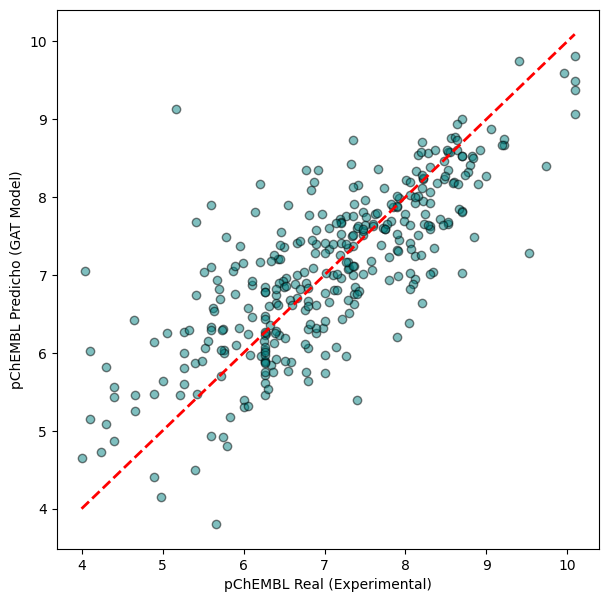

In [9]:
# Predecimos
test_pred = model.predict(test_dataset)
test_true = test_dataset.y

plt.figure(figsize=(7, 7))
plt.scatter(test_true, test_pred, alpha=0.5, c='teal', edgecolors='k')
plt.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
plt.xlabel('pChEMBL Real (Experimental)')
plt.ylabel('pChEMBL Predicho (GAT Model)')
plt.title(f'Validación Externa (Test Set)\n$R^2$ Final: {test_score:.3f}')
plt.tight_layout()
plt.show()

In [10]:
# 1. Definimos la misma arquitectura (IMPORTANTE: debe ser idéntica)
best_model = GATModel(
    n_tasks=1,
    graph_attention_layers=[16, 16, 16],
    n_attention_heads=8,
    mode='regression',
    model_dir="mejor_modelo_60" # La carpeta que pusiste en el Callback
)

# 2. Restauramos los pesos del "Mejor Momento"
best_model.restore() 

print("¡Mejor modelo cargado con éxito desde el checkpoint!")

¡Mejor modelo cargado con éxito desde el checkpoint!


/home/alfon/.pyenv/versions/miniconda3-latest/envs/bioDL/lib/python3.11/site-packages/deepchem/models/torch_models/torch_model.py:1078: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

In [11]:
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

train_score = best_model.evaluate(train_dataset, [metric])
test_score = best_model.evaluate(test_dataset, [metric])

print(f"R² Final Entrenamiento: {train_score['pearson_r2_score']:.3f}")
print(f"R² Final Test (EL DATO ORO): {test_score['pearson_r2_score']:.3f}")

R² Final Entrenamiento: 0.239
R² Final Test (EL DATO ORO): 0.294
